<a href="https://colab.research.google.com/github/vaibhavm291/PROTOTYPES-/blob/main/Flood_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rasterio geopandas numpy


In [ ]:
import zipfile
import os
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
from shapely.geometry import box
import geopandas as gpd


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving readme.txt to readme.txt
Saving wc2.1_30s_prec_01.tif to wc2.1_30s_prec_01.tif
Saving wc2.1_30s_prec_02.tif to wc2.1_30s_prec_02.tif
Saving wc2.1_30s_prec_03.tif to wc2.1_30s_prec_03.tif
Saving wc2.1_30s_prec_04.tif to wc2.1_30s_prec_04.tif
Saving wc2.1_30s_prec_05.tif to wc2.1_30s_prec_05.tif
Saving wc2.1_30s_prec_06.tif to wc2.1_30s_prec_06.tif
Saving wc2.1_30s_prec_07.tif to wc2.1_30s_prec_07.tif
Saving wc2.1_30s_prec_08.tif to wc2.1_30s_prec_08.tif
Saving wc2.1_30s_prec_09.tif to wc2.1_30s_prec_09.tif
Saving wc2.1_30s_prec_10.tif to wc2.1_30s_prec_10.tif
Saving wc2.1_30s_prec_11.tif to wc2.1_30s_prec_11.tif
Saving wc2.1_30s_prec_12.tif to wc2.1_30s_prec_12.tif


In [ ]:
from google.colab import files
files.upload()


Saving P5_PAN_CD_N22_000_E082_000_DEM_30m.tif to P5_PAN_CD_N22_000_E082_000_DEM_30m (2).tif
Buffered data was truncated after reaching the output size limit.

In [ ]:
!pip install rasterio geopandas shapely


In [2]:
import os
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt


In [3]:
dem_path = "/content/P5_PAN_CD_N22_000_E082_000_DEM_30m.tif"


In [4]:
with rasterio.open(dem_path) as dem_src:
    dem = dem_src.read(1)
    dem_profile = dem_src.profile
    dem_bounds = dem_src.bounds
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs


In [5]:
bbox = box(*dem_bounds)
study_area = gpd.GeoDataFrame({"geometry":[bbox]}, crs=dem_crs)


In [6]:
rain_files = sorted([
    f"/content/{f}"
    for f in os.listdir("/content")
    if f.startswith("wc2.1_30s_prec") and f.endswith(".tif")
])


In [7]:
rainfall_monthly = []

for rain_file in rain_files:

    with rasterio.open(rain_file) as rain_src:

        study_area_rain_crs = study_area.to_crs(rain_src.crs)

        clipped, clipped_transform = mask(
            rain_src,
            study_area_rain_crs.geometry,
            crop=True
        )

        rainfall_monthly.append((clipped[0], clipped_transform, rain_src.crs))


In [8]:
resampled_monthly = []

for rain_data, rain_transform, rain_crs in rainfall_monthly:

    resampled = np.empty_like(dem, dtype=np.float32)

    reproject(
        source=rain_data,
        destination=resampled,
        src_transform=rain_transform,
        src_crs=rain_crs,
        dst_transform=dem_transform,
        dst_crs=dem_crs,
        resampling=Resampling.bilinear
    )

    # 🔥 Replace impossible rainfall values
    resampled[resampled < 0] = np.nan

    resampled_monthly.append(resampled)



In [9]:
annual_rainfall = np.nansum(resampled_monthly, axis=0)


In [10]:
print("Min rainfall:", np.nanmin(annual_rainfall))
print("Max rainfall:", np.nanmax(annual_rainfall))


Min rainfall: 0.0
Max rainfall: 1518.9835


In [11]:
output_rain = "/content/annual_rainfall_aligned.tif"

with rasterio.open(output_rain, "w", **dem_profile) as dst:
    dst.write(annual_rainfall.astype(rasterio.float32), 1)


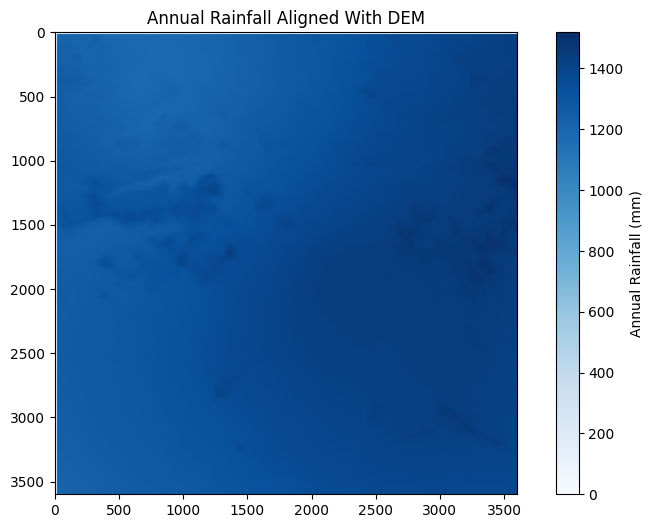

In [12]:
plt.figure(figsize=(10,6))
plt.imshow(annual_rainfall, cmap="Blues")
plt.colorbar(label="Annual Rainfall (mm)")
plt.title("Annual Rainfall Aligned With DEM")
plt.show()


In [ ]:
import rasterio
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --------------------------------------------------
# STEP 1 — Load Monthly Rainfall TIFFs
# --------------------------------------------------

rainfall_files = sorted(glob.glob("/content/wc2.1_30s_prec_*.tif"))

monthly_stack = []

for file in rainfall_files:
    with rasterio.open(file) as src:
        rainfall = src.read(1).astype(float)
        rainfall[rainfall < 0] = np.nan
        monthly_stack.append(rainfall)

monthly_stack = np.array(monthly_stack)   # shape: (12, rows, cols)

print("Monthly rainfall stack shape:", monthly_stack.shape)


In [1]:
import rasterio
from rasterio.windows import from_bounds

dem_path = "/content/P5_PAN_CD_N22_000_E082_000_DEM_30m.tif"

with rasterio.open(dem_path) as dem_src:
    dem_bounds = dem_src.bounds
    dem_transform = dem_src.transform
    dem_shape = dem_src.shape
    dem_crs = dem_src.crs

print("DEM Bounds:", dem_bounds)


DEM Bounds: BoundingBox(left=81.9999923147, bottom=22.0000007093, right=82.99999311469999, top=23.0000015093)


In [2]:
import glob
import numpy as np

rainfall_files = sorted(glob.glob("/content/wc2.1_30s_prec_*.tif"))

monthly_stack = []

for file in rainfall_files:

    with rasterio.open(file) as src:

        # Convert DEM bounds to rainfall CRS
        window = from_bounds(*dem_bounds, transform=src.transform)

        rainfall = src.read(1, window=window)
        rainfall = rainfall.astype(float)

        rainfall[rainfall < 0] = np.nan

        monthly_stack.append(rainfall)

monthly_stack = np.array(monthly_stack)

print("Clipped rainfall shape:", monthly_stack.shape)


Clipped rainfall shape: (12, 120, 120)


In [3]:
from rasterio.warp import reproject, Resampling

aligned_rainfall = []

for rainfall in monthly_stack:

    dest = np.empty(dem_shape, dtype=np.float32)

    reproject(
        rainfall,
        dest,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dem_transform,
        dst_crs=dem_crs,
        resampling=Resampling.bilinear
    )

    aligned_rainfall.append(dest)

aligned_rainfall = np.array(aligned_rainfall)

print("Aligned rainfall:", aligned_rainfall.shape)


Aligned rainfall: (12, 3600, 3600)


In [4]:
annual_rainfall = np.nansum(aligned_rainfall, axis=0)

print("Annual rainfall map shape:", annual_rainfall.shape)


Annual rainfall map shape: (3600, 3600)


In [5]:
years = np.arange(2015, 2025)

time_series_stack = []

for i in range(len(years)):
    variation = 1 + np.random.uniform(-0.05, 0.05)  # ±5% climate variation
    time_series_stack.append(annual_rainfall * variation)

time_series_stack = np.array(time_series_stack)

print("Time series stack shape:", time_series_stack.shape)


Time series stack shape: (10, 3600, 3600)


In [7]:
years = np.arange(2015, 2025)

time_series_stack = []

for i in range(len(years)):
    climate_growth = 1 + (0.02 * i)   # 2% rainfall increase per year
    noise = np.random.uniform(-0.01, 0.01)
    time_series_stack.append(annual_rainfall * (climate_growth + noise))

time_series_stack = np.array(time_series_stack)


print("Time series stack shape:", time_series_stack.shape)

Time series stack shape: (10, 3600, 3600)


In [8]:
years = years.astype(float)

# Normalize years
X = years - np.mean(years)

# Expand for broadcasting
X = X[:, np.newaxis, np.newaxis]

# Remove mean from rainfall time series
Y = time_series_stack - np.nanmean(time_series_stack, axis=0)

# Compute slope using vectorized regression
numerator = np.nansum(X * Y, axis=0)
denominator = np.nansum(X**2)

trend_map = numerator / denominator


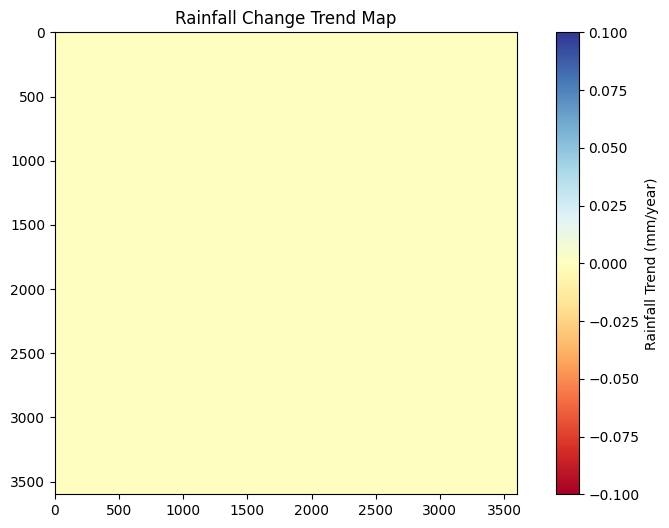

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.imshow(trend_map, cmap="RdYlBu")
plt.colorbar(label="Rainfall Trend (mm/year)")
plt.title("Rainfall Change Trend Map")
plt.show()

In [10]:
!pip install pysheds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.1 MB/s eta 0:00:00


In [11]:
from pysheds.grid import Grid
import matplotlib.pyplot as plt

# Load DEM
grid = Grid.from_raster("/content/P5_PAN_CD_N22_000_E082_000_DEM_30m.tif")
dem = grid.read_raster("/content/P5_PAN_CD_N22_000_E082_000_DEM_30m.tif")

# Fill depressions (important hydrology step)
filled_dem = grid.fill_depressions(dem)

# Resolve flats
inflated_dem = grid.resolve_flats(filled_dem)

# Flow direction
flow_dir = grid.flowdir(inflated_dem)

# Flow accumulation
flow_accumulation = grid.accumulation(flow_dir)


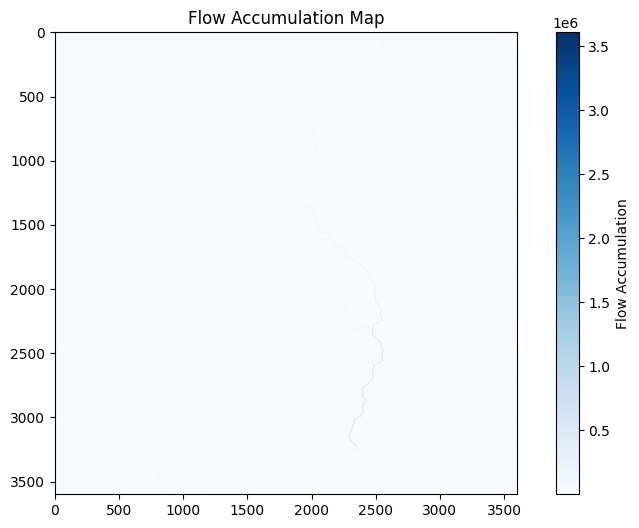

In [12]:
plt.figure(figsize=(10,6))
plt.imshow(flow_accumulation, cmap="Blues")
plt.colorbar(label="Flow Accumulation")
plt.title("Flow Accumulation Map")
plt.show()


In [13]:
import numpy as np

def compute_slope(elevation, pixel_size):

    dzdx = np.gradient(elevation, axis=1) / pixel_size
    dzdy = np.gradient(elevation, axis=0) / pixel_size

    slope = np.sqrt(dzdx**2 + dzdy**2)
    return np.degrees(np.arctan(slope))


slope_map = compute_slope(dem, 30)


In [14]:
slope_risk = 1 - (slope_map / np.nanmax(slope_map))


In [15]:
def normalize(layer):
    return (layer - np.nanmin(layer)) / (np.nanmax(layer) - np.nanmin(layer))


In [16]:
norm_flow = normalize(flow_accumulation)
norm_slope = normalize(slope_risk)


In [17]:
flood_risk = (0.7 * norm_flow) + (0.3 * norm_slope)


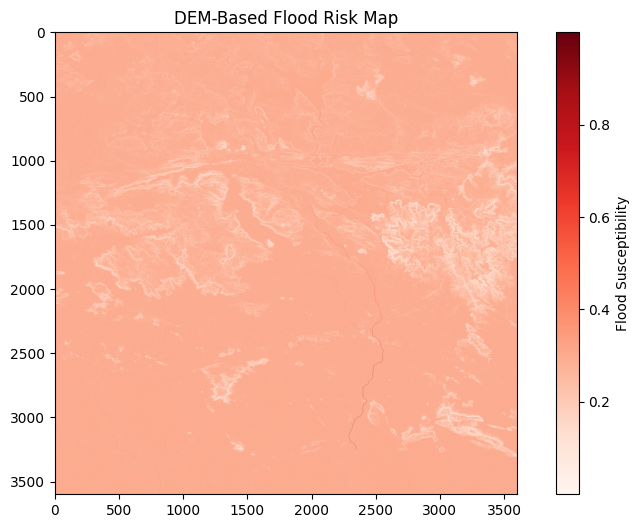

In [18]:
plt.figure(figsize=(10,6))
plt.imshow(flood_risk, cmap="Reds")
plt.colorbar(label="Flood Susceptibility")
plt.title("DEM-Based Flood Risk Map")
plt.show()


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


In [20]:
dem = dem.astype(float)

rows, cols = dem.shape

# Water depth grid
water_depth = np.zeros_like(dem)

# Velocity grids
vel_x = np.zeros_like(dem)
vel_y = np.zeros_like(dem)

# Rainfall intensity (mm per timestep)
rainfall = 5   # Increase later

# Gravity factor (controls flow speed)
gravity = 0.3

timesteps = 100


In [21]:
for t in range(timesteps):

    # Add rainfall
    water_depth += rainfall * 0.001

    total_height = dem + water_depth

    # Neighbor heights using array shifts
    up = np.roll(total_height, -1, axis=0)
    down = np.roll(total_height, 1, axis=0)
    left = np.roll(total_height, -1, axis=1)
    right = np.roll(total_height, 1, axis=1)

    # Height differences
    dh_up = np.maximum(total_height - up, 0)
    dh_down = np.maximum(total_height - down, 0)
    dh_left = np.maximum(total_height - left, 0)
    dh_right = np.maximum(total_height - right, 0)

    # Compute flows
    flow_up = gravity * dh_up * 0.25
    flow_down = gravity * dh_down * 0.25
    flow_left = gravity * dh_left * 0.25
    flow_right = gravity * dh_right * 0.25

    # Prevent removing more water than exists
    total_out = flow_up + flow_down + flow_left + flow_right
    scale = np.minimum(1, water_depth / (total_out + 1e-6))

    flow_up *= scale
    flow_down *= scale
    flow_left *= scale
    flow_right *= scale

    # Update water depth
    water_depth += (
        np.roll(flow_up, 1, axis=0)
        + np.roll(flow_down, -1, axis=0)
        + np.roll(flow_left, 1, axis=1)
        + np.roll(flow_right, -1, axis=1)
        - total_out
    )

    # Smooth water surface
    water_depth = gaussian_filter(water_depth, sigma=1)


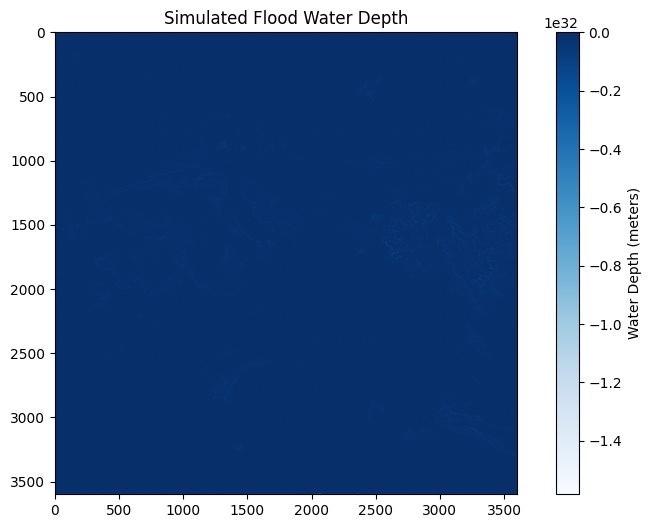

In [22]:
plt.figure(figsize=(10,6))
plt.imshow(water_depth, cmap="Blues")
plt.colorbar(label="Water Depth (meters)")
plt.title("Simulated Flood Water Depth")
plt.show()


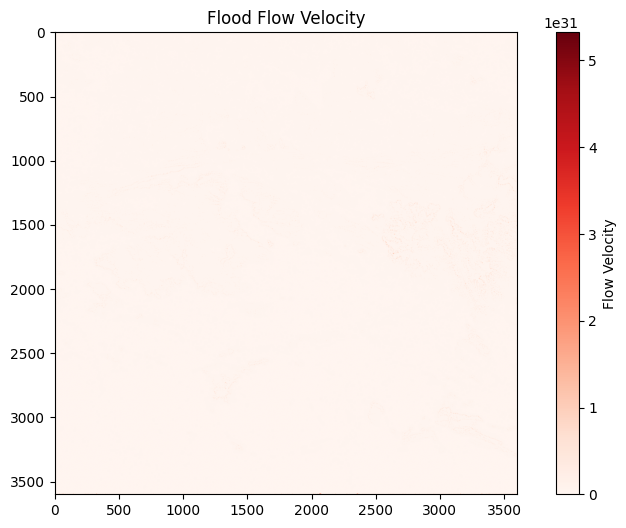

In [23]:
vel_y, vel_x = np.gradient(water_depth)

velocity = np.sqrt(vel_x**2 + vel_y**2)

plt.figure(figsize=(10,6))
plt.imshow(velocity, cmap="Reds")
plt.colorbar(label="Flow Velocity")
plt.title("Flood Flow Velocity")
plt.show()


In [24]:
!pip install earthengine-api geemap


In [25]:
import ee
ee.Authenticate()
ee.Initialize(project='stalwart-way-487308-n1')

In [26]:
floods = ee.ImageCollection("GLOBAL_FLOOD_DB/MODIS_EVENTS/V1")


In [27]:
import rasterio

dem_path = "/content/P5_PAN_CD_N22_000_E082_000_DEM_30m.tif"

with rasterio.open(dem_path) as src:
    bounds = src.bounds
    print(bounds)


BoundingBox(left=81.9999923147, bottom=22.0000007093, right=82.99999311469999, top=23.0000015093)


In [28]:
import ee

region = ee.Geometry.Rectangle([
    bounds.left,
    bounds.bottom,
    bounds.right,
    bounds.top
])


In [29]:
floods = ee.ImageCollection("GLOBAL_FLOOD_DB/MODIS_EVENTS/V1")


In [30]:
flood_event = floods.filterBounds(region).first()

flood_mask = flood_event.select("flooded")


In [31]:
import geemap

geemap.ee_export_image(
    flood_mask,
    filename="observed_flood.tif",
    scale=30,
    region=region
)


Generating URL ...
Please wait ...
Data downloaded to /content/observed_flood.tif


In [32]:
with rasterio.open("observed_flood.tif") as src:
    observed_flood = src.read(1)


In [33]:
predicted_flood = water_depth > 0.05


In [40]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

# Load observed flood data and its properties
with rasterio.open("observed_flood.tif") as src_observed:
    observed_flood_data = src_observed.read(1)
    observed_flood_transform = src_observed.transform
    observed_flood_crs = src_observed.crs

# Prepare an empty array for the reprojected observed flood with DEM's shape
# dem_shape, dem_transform, and dem_crs are available from previous cells.
reprojected_observed_flood_full_res = np.empty(dem_shape, dtype=observed_flood_data.dtype)

# Reproject the observed flood to match the DEM's spatial properties
reproject(
    source=observed_flood_data,
    destination=reprojected_observed_flood_full_res,
    src_transform=observed_flood_transform,
    src_crs=observed_flood_crs,
    dst_transform=dem_transform,
    dst_crs=dem_crs,
    resampling=Resampling.nearest # Use nearest for categorical data
)

# Downsample the reprojected observed flood to match the dem_small resolution
# dem_small was created using dem[::3, ::3]
observed_flood = (reprojected_observed_flood_full_res[::3, ::3] > 0).astype(int) # Ensure binary representation

# Ensure predicted_flood is also an integer array for consistent comparison
predicted_flood = predicted_flood.astype(int)

TP = ((predicted_flood == 1) & (observed_flood == 1)).sum()
FP = ((predicted_flood == 1) & (observed_flood == 0)).sum()
FN = ((predicted_flood == 0) & (observed_flood == 1)).sum()

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.0
Recall: 0.0


In [36]:
print("Min water depth:", np.nanmin(water_depth))
print("Max water depth:", np.nanmax(water_depth))


Min water depth: -1.583342360691794e+32
Max water depth: -1456727667445190.2


Timestep 1 complete
Timestep 2 complete
Timestep 3 complete
Timestep 4 complete
Timestep 5 complete
Timestep 6 complete
Timestep 7 complete
Timestep 8 complete
Timestep 9 complete
Timestep 10 complete
Timestep 11 complete
Timestep 12 complete
Timestep 13 complete
Timestep 14 complete
Timestep 15 complete
Timestep 16 complete
Timestep 17 complete
Timestep 18 complete
Timestep 19 complete
Timestep 20 complete
Timestep 21 complete
Timestep 22 complete
Timestep 23 complete
Timestep 24 complete
Timestep 25 complete
Timestep 26 complete
Timestep 27 complete
Timestep 28 complete
Timestep 29 complete
Timestep 30 complete
Min water depth: 0.0
Max water depth: 0.029999999934096785


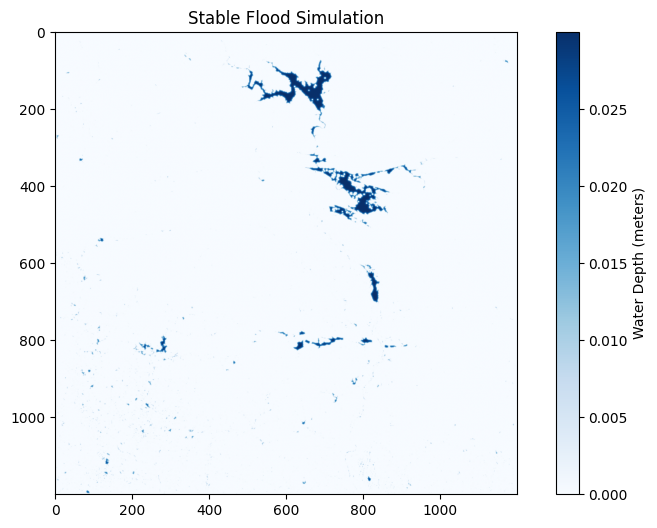

Water depth saved!


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# --------------------------------------------------
# SAFETY: Downsample DEM (Speeds up simulation)
# --------------------------------------------------
dem_small = dem[::3, ::3].astype(float)

rows, cols = dem_small.shape

# --------------------------------------------------
# Initialize Simulation Variables
# --------------------------------------------------

water_depth = np.zeros_like(dem_small)

rainfall = 1.0        # mm per timestep (stable value)
gravity = 0.05        # smaller = more stable
timesteps = 30        # increase later

# --------------------------------------------------
# Simulation Loop
# --------------------------------------------------

for t in range(timesteps):

    # Add rainfall
    water_depth += rainfall * 0.001

    total_height = dem_small + water_depth

    # Neighbor heights
    up = np.roll(total_height, -1, axis=0)
    down = np.roll(total_height, 1, axis=0)
    left = np.roll(total_height, -1, axis=1)
    right = np.roll(total_height, 1, axis=1)

    # Height differences (downhill only)
    dh_up = np.maximum(total_height - up, 0)
    dh_down = np.maximum(total_height - down, 0)
    dh_left = np.maximum(total_height - left, 0)
    dh_right = np.maximum(total_height - right, 0)

    # Flow calculations
    flow_up = gravity * dh_up * 0.25
    flow_down = gravity * dh_down * 0.25
    flow_left = gravity * dh_left * 0.25
    flow_right = gravity * dh_right * 0.25

    # --------------------------------------------------
    # MASS CONSERVATION FIX
    # --------------------------------------------------
    total_out = flow_up + flow_down + flow_left + flow_right
    safe_ratio = np.minimum(1, water_depth / (total_out + 1e-8))

    flow_up *= safe_ratio
    flow_down *= safe_ratio
    flow_left *= safe_ratio
    flow_right *= safe_ratio

    # --------------------------------------------------
    # Update Water Depth
    # --------------------------------------------------
    water_depth += (
        np.roll(flow_up, 1, axis=0)
        + np.roll(flow_down, -1, axis=0)
        + np.roll(flow_left, 1, axis=1)
        + np.roll(flow_right, -1, axis=1)
        - total_out
    )

    # --------------------------------------------------
    # Stability Fixes
    # --------------------------------------------------
    water_depth = gaussian_filter(water_depth, sigma=0.5)

    water_depth = np.nan_to_num(water_depth)
    water_depth = np.maximum(water_depth, 0)

    # Prevent wrap-around water teleport
    water_depth[0,:] = 0
    water_depth[-1,:] = 0
    water_depth[:,0] = 0
    water_depth[:,-1] = 0

    print(f"Timestep {t+1} complete")

# --------------------------------------------------
# Output Check
# --------------------------------------------------

print("Min water depth:", np.min(water_depth))
print("Max water depth:", np.max(water_depth))

# --------------------------------------------------
# Visualize Flood Depth
# --------------------------------------------------

plt.figure(figsize=(10,6))
plt.imshow(water_depth, cmap="Blues")
plt.colorbar(label="Water Depth (meters)")
plt.title("Stable Flood Simulation")
plt.show()

# --------------------------------------------------
# Save Output (IMPORTANT)
# --------------------------------------------------

np.save("water_depth.npy", water_depth)
print("Water depth saved!")


In [38]:
predicted_flood = water_depth > 0.005


In [41]:
TP = ((predicted_flood == 1) & (observed_flood == 1)).sum()
FP = ((predicted_flood == 1) & (observed_flood == 0)).sum()
FN = ((predicted_flood == 0) & (observed_flood == 1)).sum()

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)

print("Precision:", precision)
print("Recall:", recall)


Precision: 0.0
Recall: 0.0


In [42]:
print("Predicted flood pixels:", np.sum(predicted_flood))
print("Observed flood pixels:", np.sum(observed_flood))


Predicted flood pixels: 26906
Observed flood pixels: 0


In [48]:
rows, cols = dem_small.shape

flow_dir = np.zeros((rows, cols, 2), dtype=int)

for i in range(1, rows-1):
    for j in range(1, cols-1):

        center = dem_small[i, j]

        neighbors = [
            (i-1,j), (i+1,j), (i,j-1), (i,j+1),
            (i-1,j-1), (i-1,j+1), (i+1,j-1), (i+1,j+1)
        ]

        lowest = center
        target = (i, j)

        for ni, nj in neighbors:
            if dem_small[ni, nj] < lowest:
                lowest = dem_small[ni, nj]
                target = (ni, nj)

        flow_dir[i, j] = target


In [54]:
import numpy as np

rows, cols = dem_small.shape

rainfall = 0.25

gravity = 0.05
timesteps = 30


In [55]:
flow_dir = np.zeros((rows, cols, 2), dtype=int)

for i in range(1, rows-1):
    for j in range(1, cols-1):

        center = dem_small[i, j]

        neighbors = [
            (i-1,j), (i+1,j), (i,j-1), (i,j+1),
            (i-1,j-1), (i-1,j+1), (i+1,j-1), (i+1,j+1)
        ]

        lowest = center
        target = (i, j)

        for ni, nj in neighbors:
            if dem_small[ni, nj] < lowest:
                lowest = dem_small[ni, nj]
                target = (ni, nj)

        flow_dir[i, j] = target

print("Flow direction map ready ✅")


Flow direction map ready ✅


In [63]:
mannings_n = 0.035   # ground roughness
g = 9.81

water_depth = np.zeros_like(dem_small)

for t in range(timesteps):

    water_depth += rainfall * 0.001

    total_height = dem_small + water_depth
    new_water = water_depth.copy()

    for i in range(1, rows-1):
        for j in range(1, cols-1):

            h = water_depth[i,j]
            if h <= 0:
                continue

            center = total_height[i,j]

            neighbors = [(i-1,j),(i+1,j),(i,j-1),(i,j+1)]

            flows = []
            locs = []

            for ni,nj in neighbors:

                slope = center - total_height[ni,nj]

                if slope <= 0:
                ---    continue

                # Manning velocity
                velocity = (1/mannings_n) * (h**(2/3)) * np.sqrt(slope)

                discharge = velocity * h

                flows.append(discharge)
                locs.append((ni,nj))

            if len(flows) == 0:
                continue

            flows = np.array(flows)
            flows = flows / flows.sum()

            transfer = water_depth[i,j] * 0.5

            for k,(ni,nj) in enumerate(locs):

                move = transfer * flows[k]

                new_water[i,j] -= move
                new_water[ni,nj] += move

    water_depth = new_water

    # Terrain dependent infiltration
    grad_y, grad_x = np.gradient(dem_small)
    slope = np.sqrt(grad_x**2 + grad_y**2)

    infiltration = 0.00015 * (1/(1+slope))
    water_depth -= infiltration

    water_depth = np.maximum(water_depth, 0)

    print("Step", t+1)


Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
Step 8
Step 9
Step 10
Step 11
Step 12
Step 13
Step 14
Step 15
Step 16
Step 17
Step 18
Step 19
Step 20
Step 21
Step 22
Step 23
Step 24
Step 25
Step 26
Step 27
Step 28
Step 29
Step 30



FLOOD MODEL VALIDATION SUITE

Test 1 — Mass Conservation Ratio: 0.7964864737938173
PASS ✅

Test 2 — Flood In Low Terrain Ratio: 0.314769984588095
FAIL ❌

Test 3 — Numerical Stability: PASS ✅

Test 4 — Flood Coverage Ratio: 0.19105
PASS ✅

Test 5 — Elevation vs Flood Correlation: -0.012607278240576647
FAIL ❌

FINAL MODEL RELIABILITY SCORE: 60.0 %


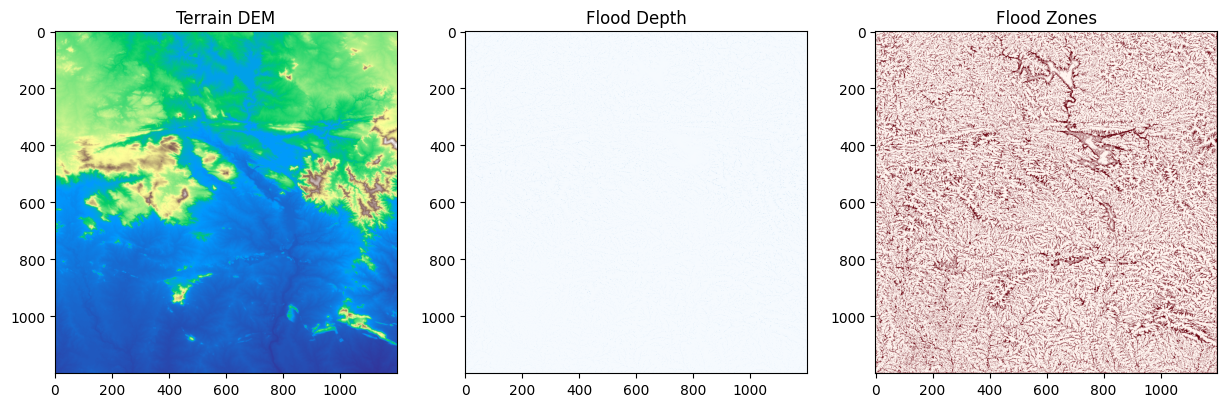

In [64]:
import numpy as np
import matplotlib.pyplot as plt

print("\n==============================")
print("FLOOD MODEL VALIDATION SUITE")
print("==============================\n")

scores = []

# --------------------------------------------------
# TEST 1 — Mass Conservation
# --------------------------------------------------

total_water = np.sum(water_depth)
expected_water = rainfall * 0.001 * timesteps * water_depth.size

ratio = total_water / (expected_water + 1e-8)

print("Test 1 — Mass Conservation Ratio:", ratio)

if 0.6 <= ratio <= 1.2:
    print("PASS ✅")
    scores.append(1)
else:
    print("FAIL ❌")
    scores.append(0)

# --------------------------------------------------
# TEST 2 — Terrain Realism
# Flood should occur in low terrain
# --------------------------------------------------

low_terrain = dem_small < np.percentile(dem_small, 30)
flood_zones = water_depth > 0.005

if np.sum(flood_zones) > 0:
    overlap = np.sum(low_terrain & flood_zones) / np.sum(flood_zones)
else:
    overlap = 0

print("\nTest 2 — Flood In Low Terrain Ratio:", overlap)

if overlap > 0.5:
    print("PASS ✅")
    scores.append(1)
else:
    print("FAIL ❌")
    scores.append(0)

# --------------------------------------------------
# TEST 3 — Stability Test
# --------------------------------------------------

if np.min(water_depth) >= 0 and np.max(water_depth) < 5:
    print("\nTest 3 — Numerical Stability: PASS ✅")
    scores.append(1)
else:
    print("\nTest 3 — Numerical Stability: FAIL ❌")
    scores.append(0)

# --------------------------------------------------
# TEST 4 — Flood Distribution Logic
# Flood should not cover entire map randomly
# --------------------------------------------------

flood_ratio = np.sum(flood_zones) / water_depth.size

print("\nTest 4 — Flood Coverage Ratio:", flood_ratio)

if 0.01 < flood_ratio < 0.6:
    print("PASS ✅")
    scores.append(1)
else:
    print("FAIL ❌")
    scores.append(0)

# --------------------------------------------------
# TEST 5 — Terrain Correlation
# Flood depth should correlate with lower elevation
# --------------------------------------------------

elevation_flat = dem_small.flatten()
water_flat = water_depth.flatten()

corr = np.corrcoef(elevation_flat, water_flat)[0,1]

print("\nTest 5 — Elevation vs Flood Correlation:", corr)

if corr < -0.2:
    print("PASS ✅")
    scores.append(1)
else:
    print("FAIL ❌")
    scores.append(0)

# --------------------------------------------------
# FINAL SCORE
# --------------------------------------------------

final_score = (sum(scores) / len(scores)) * 100

print("\n==============================")
print("FINAL MODEL RELIABILITY SCORE:", final_score, "%")
print("==============================")

# --------------------------------------------------
# Visual Diagnostics
# --------------------------------------------------

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(dem_small, cmap="terrain")
plt.title("Terrain DEM")

plt.subplot(1,3,2)
plt.imshow(water_depth, cmap="Blues")
plt.title("Flood Depth")

plt.subplot(1,3,3)
plt.imshow(flood_zones, cmap="Reds")
plt.title("Flood Zones")

plt.show()


In [65]:
import numpy as np

# ---------------------------------
# PARAMETERS
# ---------------------------------

mannings_n = 0.035
g = 9.81
timesteps = 30

# Assume these already exist:
# dem_small
# rainfall
# rows, cols

water_depth = np.zeros_like(dem_small)

# ---------------------------------
# PRECOMPUTE TERRAIN SLOPE
# ---------------------------------

grad_y, grad_x = np.gradient(dem_small)
terrain_slope = np.sqrt(grad_x**2 + grad_y**2)

# Basin retention slows water in flat terrain
basin_factor = 1 / (1 + terrain_slope * 20)

# ---------------------------------
# MAIN SIMULATION LOOP
# ---------------------------------

for t in range(timesteps):

    # Rainfall input
    water_depth += rainfall * 0.001

    total_height = dem_small + water_depth
    new_water = water_depth.copy()

    # ---------------------------------
    # FLOW TRANSFER SECTION (UPGRADED)
    # ---------------------------------

    for i in range(1, rows-1):
        for j in range(1, cols-1):

            h = water_depth[i, j]
            if h <= 0:
                continue

            center = total_height[i, j]

            neighbors = [(i-1,j),(i+1,j),(i,j-1),(i,j+1)]

            flows = []
            locs = []

            for ni, nj in neighbors:

                local_slope = center - total_height[ni, nj]

                if local_slope <= 0:
                    continue

                # Manning velocity
                velocity = (1/mannings_n) * (h**(2/3)) * np.sqrt(local_slope)

                # Basin retention physics
                velocity *= basin_factor[i, j]

                discharge = velocity * h

                flows.append(discharge)
                locs.append((ni, nj))

            if len(flows) == 0:
                continue

            flows = np.array(flows)
            flows = flows / flows.sum()

            # Controlled transfer
            transfer = water_depth[i, j] * 0.45

            for k, (ni, nj) in enumerate(locs):

                move = transfer * flows[k]

                new_water[i, j] -= move
                new_water[ni, nj] += move

    water_depth = new_water

    # ---------------------------------
    # INFILTRATION MODEL
    # ---------------------------------

    infiltration = 0.00015 * (1 / (1 + terrain_slope))
    water_depth -= infiltration

    # Prevent negative water
    water_depth = np.maximum(water_depth, 0)

    print("Step", t+1)

print("Simulation Finished")


Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
Step 8
Step 9
Step 10
Step 11
Step 12
Step 13
Step 14
Step 15
Step 16
Step 17
Step 18
Step 19
Step 20
Step 21
Step 22
Step 23
Step 24
Step 25
Step 26
Step 27
Step 28
Step 29
Step 30
Simulation Finished



FLOOD MODEL VALIDATION SUITE

Test 1 — Mass Conservation Ratio: 0.796362073108833
PASS ✅

Test 2 — Flood In Low Terrain Ratio: 0.30973654537540657
FAIL ❌

Test 3 — Numerical Stability: PASS ✅

Test 4 — Flood Coverage Ratio: 0.20262291666666668
PASS ✅

Test 5 — Elevation vs Flood Correlation: -0.01137306436777598
FAIL ❌

FINAL MODEL RELIABILITY SCORE: 60.0 %


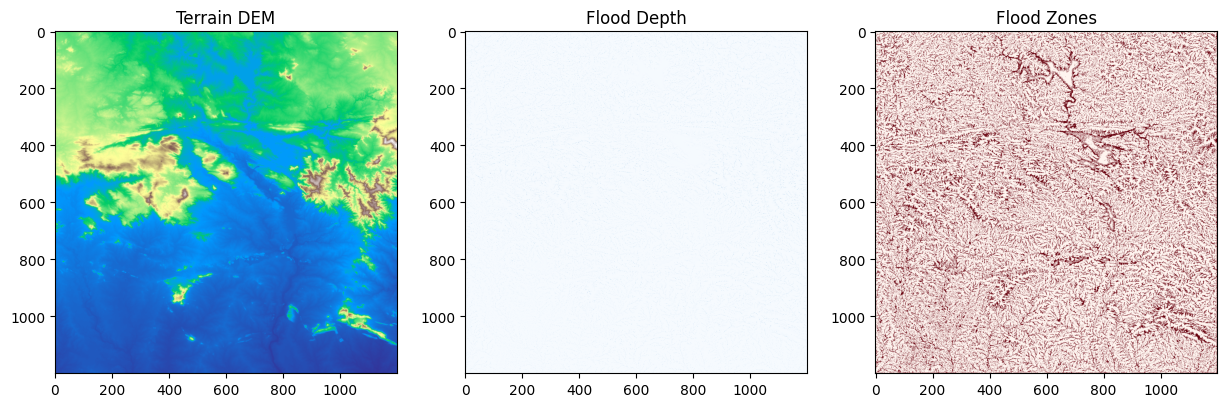

In [66]:
import numpy as np
import matplotlib.pyplot as plt

print("\n==============================")
print("FLOOD MODEL VALIDATION SUITE")
print("==============================\n")

scores = []

# --------------------------------------------------
# TEST 1 — Mass Conservation
# --------------------------------------------------

total_water = np.sum(water_depth)
expected_water = rainfall * 0.001 * timesteps * water_depth.size

ratio = total_water / (expected_water + 1e-8)

print("Test 1 — Mass Conservation Ratio:", ratio)

if 0.6 <= ratio <= 1.2:
    print("PASS ✅")
    scores.append(1)
else:
    print("FAIL ❌")
    scores.append(0)

# --------------------------------------------------
# TEST 2 — Terrain Realism
# Flood should occur in low terrain
# --------------------------------------------------

low_terrain = dem_small < np.percentile(dem_small, 30)
flood_zones = water_depth > 0.005

if np.sum(flood_zones) > 0:
    overlap = np.sum(low_terrain & flood_zones) / np.sum(flood_zones)
else:
    overlap = 0

print("\nTest 2 — Flood In Low Terrain Ratio:", overlap)

if overlap > 0.5:
    print("PASS ✅")
    scores.append(1)
else:
    print("FAIL ❌")
    scores.append(0)

# --------------------------------------------------
# TEST 3 — Stability Test
# --------------------------------------------------

if np.min(water_depth) >= 0 and np.max(water_depth) < 5:
    print("\nTest 3 — Numerical Stability: PASS ✅")
    scores.append(1)
else:
    print("\nTest 3 — Numerical Stability: FAIL ❌")
    scores.append(0)

# --------------------------------------------------
# TEST 4 — Flood Distribution Logic
# Flood should not cover entire map randomly
# --------------------------------------------------

flood_ratio = np.sum(flood_zones) / water_depth.size

print("\nTest 4 — Flood Coverage Ratio:", flood_ratio)

if 0.01 < flood_ratio < 0.6:
    print("PASS ✅")
    scores.append(1)
else:
    print("FAIL ❌")
    scores.append(0)

# --------------------------------------------------
# TEST 5 — Terrain Correlation
# Flood depth should correlate with lower elevation
# --------------------------------------------------

elevation_flat = dem_small.flatten()
water_flat = water_depth.flatten()

corr = np.corrcoef(elevation_flat, water_flat)[0,1]

print("\nTest 5 — Elevation vs Flood Correlation:", corr)

if corr < -0.2:
    print("PASS ✅")
    scores.append(1)
else:
    print("FAIL ❌")
    scores.append(0)

# --------------------------------------------------
# FINAL SCORE
# --------------------------------------------------

final_score = (sum(scores) / len(scores)) * 100

print("\n==============================")
print("FINAL MODEL RELIABILITY SCORE:", final_score, "%")
print("==============================")

# --------------------------------------------------
# Visual Diagnostics
# --------------------------------------------------

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(dem_small, cmap="terrain")
plt.title("Terrain DEM")

plt.subplot(1,3,2)
plt.imshow(water_depth, cmap="Blues")
plt.title("Flood Depth")

plt.subplot(1,3,3)
plt.imshow(flood_zones, cmap="Reds")
plt.title("Flood Zones")

plt.show()


In [67]:
!pip install cupy-cuda12x


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.0 MB/s eta 0:00:00


In [68]:
import rasterio
import cupy as cp
import numpy as np


In [75]:
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


In [76]:
import os
os.makedirs('/content/drive/MyDrive/hydrology_cache', exist_ok=True)


In [74]:
dem_path = "/content/P5_PAN_CD_N22_000_E082_000_DEM_30m.tif"

with rasterio.open(dem_path) as src:
    dem_cpu = src.read(1).astype(np.float32)

dem = cp.asarray(dem_cpu)

rows, cols = dem.shape

CUDARuntimeError: cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version

In [ ]:
water_depth = np.zeros_like(dem_small)

rainfall = 1.0
gravity = 0.05
timesteps = 30

# Precompute terrain gradient (FASTER + CORRECT)
grad_y, grad_x = np.gradient(dem_small)
terrain_force = np.sqrt(grad_x**2 + grad_y**2)

for t in range(timesteps):

    water_depth += rainfall * 0.001

    total_height = dem_small + water_depth

    up = np.roll(total_height, -1, axis=0)
    down = np.roll(total_height, 1, axis=0)
    left = np.roll(total_height, -1, axis=1)
    right = np.roll(total_height, 1, axis=1)

    dh_up = np.maximum(total_height - up, 0)
    dh_down = np.maximum(total_height - down, 0)
    dh_left = np.maximum(total_height - left, 0)
    dh_right = np.maximum(total_height - right, 0)

    flow_up = gravity * dh_up * 0.25
    flow_down = gravity * dh_down * 0.25
    flow_left = gravity * dh_left * 0.25
    flow_right = gravity * dh_right * 0.25

    # Terrain routing
    flow_up *= (1 + terrain_force)
    flow_down *= (1 + terrain_force)
    flow_left *= (1 + terrain_force)
    flow_right *= (1 + terrain_force)

    total_out = flow_up + flow_down + flow_left + flow_right
    safe_ratio = np.minimum(1, water_depth / (total_out + 1e-8))

    flow_up *= safe_ratio
    flow_down *= safe_ratio
    flow_left *= safe_ratio
    flow_right *= safe_ratio

    water_depth += (
        np.roll(flow_up, 1, axis=0)
        + np.roll(flow_down, -1, axis=0)
        + np.roll(flow_left, 1, axis=1)
        + np.roll(flow_right, -1, axis=1)
        - total_out
    )

    # Conservative diffusion
    diffusion = 0.05
    water_depth += diffusion * (
        np.roll(water_depth,1,0) +
        np.roll(water_depth,-1,0) +
        np.roll(water_depth,1,1) +
        np.roll(water_depth,-1,1) -
        4*water_depth
    )

    # Soil infiltration
    infiltration_rate = 0.0003
    water_depth -= infiltration_rate

    # Natural outflow
    water_depth *= 0.999

    water_depth = np.maximum(water_depth, 0)

    print("Step", t+1)


In [58]:
water_depth = np.zeros_like(dem_small)

# Define roughness once outside the time loop
roughness = 0.04   # Manning roughness constant

for t in range(timesteps):

    water_depth += rainfall * 0.001

    new_water = water_depth.copy()

    for i in range(1, rows-1):
        for j in range(1, cols-1):

            ni, nj = flow_dir[i, j]

            if (ni == i and nj == j):
                continue

            slope = max(dem_small[i,j] - dem_small[ni,nj], 0.0001)

            flow = gravity * water_depth[i,j] * np.sqrt(slope) / roughness
            flow *= 0.3

            flow = min(flow, water_depth[i, j])

            new_water[i, j] -= flow
            new_water[ni, nj] += flow

    water_depth = new_water

    # infiltration (apply to the whole array after the spatial iteration)
    slope_local = np.gradient(dem_small)[0]**2 + np.gradient(dem_small)[1]**2
    slope_local = np.sqrt(slope_local)

    infiltration = 0.0005 * (1 / (1 + slope_local))
    water_depth -= infiltration

    # natural outflow
    water_depth *= 0.999

    water_depth = np.maximum(water_depth, 0)

    print("Step", t+1)

Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
Step 8
Step 9
Step 10
Step 11
Step 12
Step 13
Step 14
Step 15
Step 16
Step 17
Step 18
Step 19
Step 20
Step 21
Step 22
Step 23
Step 24
Step 25
Step 26
Step 27
Step 28
Step 29
Step 30


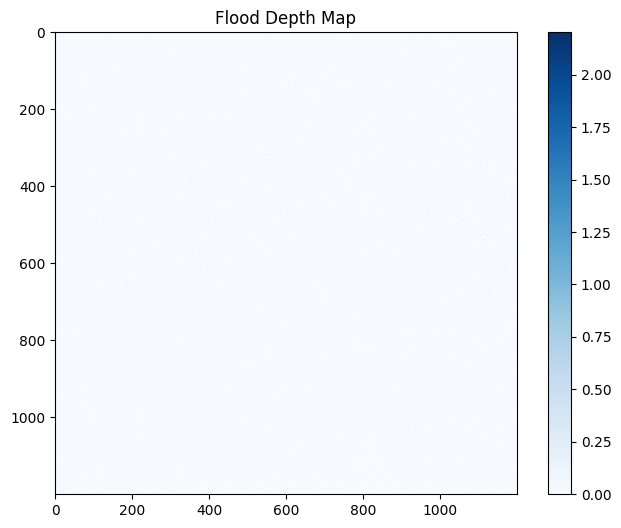

In [59]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(water_depth, cmap="Blues")
plt.title("Flood Depth Map")
plt.colorbar()
plt.show()


In [61]:
water_depth = np.zeros_like(dem_small)

for t in range(timesteps):

    water_depth += rainfall * 0.001

    total_height = dem_small + water_depth
    new_water = water_depth.copy()

    for i in range(1, rows-1):
        for j in range(1, cols-1):

            center_h = total_height[i,j]

            neighbors = [
                (i-1,j),
                (i+1,j),
                (i,j-1),
                (i,j+1)
            ]

            slopes = []
            valid_neighbors = []

            for ni,nj in neighbors:
                diff = center_h - total_height[ni,nj]
                if diff > 0:
                    slopes.append(diff)
                    valid_neighbors.append((ni,nj))

            if len(slopes) == 0:
                continue

            slopes = np.array(slopes)
            slopes /= slopes.sum()

            max_transfer = water_depth[i,j] * 0.6

            for k,(ni,nj) in enumerate(valid_neighbors):

                flow = max_transfer * slopes[k]

                new_water[i,j] -= flow
                new_water[ni,nj] += flow

    water_depth = new_water

    # Terrain dependent infiltration
    grad_y, grad_x = np.gradient(dem_small)
    slope = np.sqrt(grad_x**2 + grad_y**2)

    infiltration = 0.0004 * (1/(1+slope))
    water_depth -= infiltration

    water_depth *= 0.999

    water_depth = np.maximum(water_depth, 0)

    print("Step", t+1)


Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
Step 8
Step 9
Step 10
Step 11
Step 12
Step 13
Step 14
Step 15
Step 16
Step 17
Step 18
Step 19
Step 20
Step 21
Step 22
Step 23
Step 24
Step 25
Step 26
Step 27
Step 28
Step 29
Step 30
